# New Metrics Analysis
Run this after your existing design_insights notebook. Assumes `df` is already loaded from `insights_v3.csv` with semester normalization applied.
If running standalone, the first cell reloads everything from scratch.

In [1]:
# ── Setup: re-run this if starting fresh ──────────────────────────────────────
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, ttest_ind
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

VIOLATION_TYPES = [
    "srp", "dry", "lod", "long_chain", "cmo", "lsp",
    "god_object", "feature_envy", "long_method", "shotgun_surgery", "ocp",
    "dip", "information_expert",
]
CLASS_LEVEL  = ["srp", "god_object", "cmo", "lsp", "ocp"]
METHOD_LEVEL = ["feature_envy", "long_method", "dry", "information_expert", "dip"]
COUPLING     = ["lod", "long_chain", "shotgun_surgery"]

def normalize_semester(semester):
    if not semester or not isinstance(semester, str):
        return ("", 0)
    s = str(semester).strip()
    s = re.sub(r"\s*\([^)]*\)\s*", " ", s).strip()
    year, season = None, None
    m = re.search(r"(\d{4})\s+(Fall|Spring)", s, re.IGNORECASE)
    if m:
        year, season = int(m.group(1)), m.group(2).capitalize()
    if year is None or season is None:
        m = re.search(r"(Fall|Spring)\s+(\d{4})", s, re.IGNORECASE)
        if m:
            season, year = m.group(1).capitalize(), int(m.group(2))
    if year is None or season is None:
        return (str(semester), 0)
    return (f"{season} {year}", year * 10 + (1 if season.lower() == "spring" else 2))

csv_path = Path("insights_v3.csv")
df = pd.read_csv(csv_path)
if "semester" in df.columns:
    df["semester"] = df["semester"].fillna("").astype(str)
    normed = df["semester"].apply(normalize_semester)
    df["semester"]  = normed.apply(lambda x: x[0])
    df["sort_key"]  = normed.apply(lambda x: x[1])
    parts = df["semester"].str.split()
    df["season"] = parts.str[0].fillna("")
    df["year"]   = pd.to_numeric(parts.str[1], errors="coerce")

print(f"Loaded {len(df)} rows, {df.shape[1]} columns")
print("Columns:", list(df.columns))

Loaded 732 rows, 37 columns
Columns: ['project_id', 'semester', 'sort_key', 'season', 'year', 'repo_name', 'project_type', 'project_category', 'total_llm_violations', 'total_static_violations', 'alignment_score', 'srp_llm', 'dry_llm', 'lod_llm', 'long_chain_llm', 'cmo_llm', 'lsp_llm', 'god_object_llm', 'feature_envy_llm', 'long_method_llm', 'shotgun_surgery_llm', 'ocp_llm', 'dip_llm', 'information_expert_llm', 'srp_static', 'dry_static', 'lod_static', 'long_chain_static', 'cmo_static', 'lsp_static', 'god_object_static', 'feature_envy_static', 'long_method_static', 'shotgun_surgery_static', 'ocp_static', 'dip_static', 'information_expert_static']


---
## Metric 1: Static False-Positive Rate by Violation Type
For each violation type: what % of projects flagged by static analysis were NOT confirmed by the LLM?
High rates mean static is over-firing on Rails idioms — direct evidence for why semantic LLM reasoning is needed.

posx and posy should be finite values
posx and posy should be finite values


=== Static False-Positive Rate (static flagged but LLM did not confirm) ===
         violation  n_static_flagged  n_static_only  static_fp_rate  llm_semantic_rate
      feature_envy               435            374           0.860              0.129
               dry               132            111           0.841              0.879
               dip               331            270           0.816              0.344
information_expert               468            350           0.748              0.258
       long_method               567            407           0.718              0.231
               lsp                66             33           0.500              0.887
               srp               523             94           0.180              0.238
        god_object               485             70           0.144              0.276
               cmo               180             25           0.139              0.726
               lod               550             52   

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


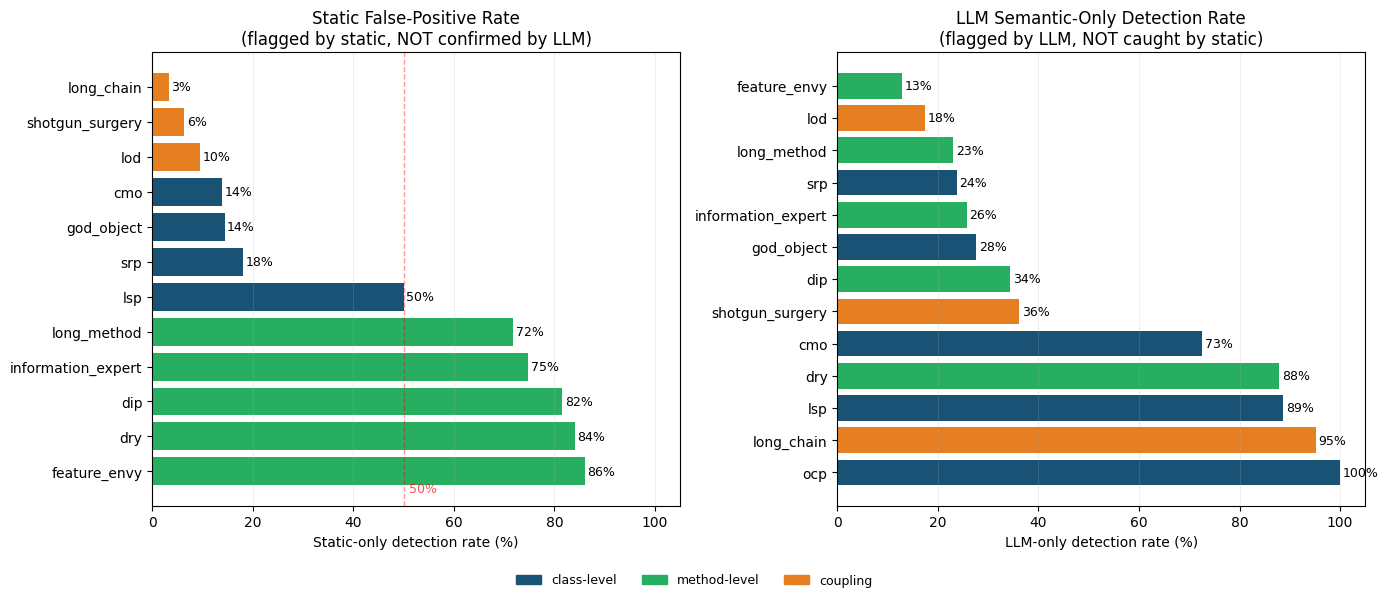


=== Key numbers ===
OCP static FP rate : [nan]
OCP LLM-only rate  : [1.]
LoD static FP rate : [0.095]
Avg static FP rate : 42.8%


In [2]:
# ── Metric 1: Static false-positive rate ──────────────────────────────────────

fp_rows = []
for vt in VIOLATION_TYPES:
    s_col = f"{vt}_static"
    l_col = f"{vt}_llm"
    if s_col not in df.columns or l_col not in df.columns:
        continue

    static_pos   = df[s_col] > 0          # static flagged
    llm_pos      = df[l_col] > 0          # LLM flagged
    n_static     = static_pos.sum()
    n_llm        = llm_pos.sum()

    # Static flagged but LLM did NOT confirm  →  likely false positive
    n_static_only = (static_pos & ~llm_pos).sum()
    # LLM flagged but static did NOT catch    →  semantic-only detection
    n_llm_only    = (~static_pos & llm_pos).sum()
    # Both agreed
    n_both        = (static_pos & llm_pos).sum()

    fp_rate = n_static_only / n_static if n_static > 0 else np.nan
    semantic_rate = n_llm_only / n_llm if n_llm > 0 else np.nan

    if vt in CLASS_LEVEL:
        cat = "class-level"
    elif vt in METHOD_LEVEL:
        cat = "method-level"
    else:
        cat = "coupling"

    fp_rows.append({
        "violation": vt,
        "category": cat,
        "n_static_flagged": int(n_static),
        "n_llm_flagged": int(n_llm),
        "n_both": int(n_both),
        "n_static_only": int(n_static_only),
        "n_llm_only": int(n_llm_only),
        "static_fp_rate": round(fp_rate, 3),
        "llm_semantic_rate": round(semantic_rate, 3),
    })

fp_df = pd.DataFrame(fp_rows).sort_values("static_fp_rate", ascending=False)
print("=== Static False-Positive Rate (static flagged but LLM did not confirm) ===")
print(fp_df[["violation","n_static_flagged","n_static_only","static_fp_rate","llm_semantic_rate"]].to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
cat_colors = {"class-level": "#1a5276", "method-level": "#27ae60", "coupling": "#e67e22"}
colors = [cat_colors[fp_df.loc[i, "category"]] for i in fp_df.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: static false-positive rate
ax = axes[0]
bars = ax.barh(fp_df["violation"], fp_df["static_fp_rate"] * 100, color=colors)
ax.set_xlabel("Static-only detection rate (%)")
ax.set_title("Static False-Positive Rate\n(flagged by static, NOT confirmed by LLM)")
ax.axvline(50, color="red", linestyle="--", alpha=0.4, linewidth=1)
ax.text(51, -0.6, "50%", fontsize=9, color="red", alpha=0.7)
for i, (v, r) in enumerate(zip(fp_df["violation"], fp_df["static_fp_rate"])):
    ax.text(r * 100 + 0.5, i, f"{r:.0%}", va="center", fontsize=9)
ax.set_xlim(0, 105)
ax.grid(True, alpha=0.2, axis="x")

# Right: LLM semantic-only rate (caught by LLM but not static)
fp_df_s = fp_df.sort_values("llm_semantic_rate", ascending=False)
colors2  = [cat_colors[fp_df_s.loc[i, "category"]] for i in fp_df_s.index]
ax2 = axes[1]
ax2.barh(fp_df_s["violation"], fp_df_s["llm_semantic_rate"] * 100, color=colors2)
ax2.set_xlabel("LLM-only detection rate (%)")
ax2.set_title("LLM Semantic-Only Detection Rate\n(flagged by LLM, NOT caught by static)")
for i, (v, r) in enumerate(zip(fp_df_s["violation"], fp_df_s["llm_semantic_rate"])):
    ax2.text(r * 100 + 0.5, i, f"{r:.0%}", va="center", fontsize=9)
ax2.set_xlim(0, 105)
ax2.grid(True, alpha=0.2, axis="x")

legend_patches = [mpatches.Patch(color=c, label=k) for k, c in cat_colors.items()]
fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=9, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(FIG_DIR / "metric1_static_fp_rate.png", dpi=150, bbox_inches="tight")
plt.show()

# Key numbers to report
print("\n=== Key numbers ===")
print(f"OCP static FP rate : {fp_df[fp_df.violation=='ocp']['static_fp_rate'].values}")
print(f"OCP LLM-only rate  : {fp_df[fp_df.violation=='ocp']['llm_semantic_rate'].values}")
print(f"LoD static FP rate : {fp_df[fp_df.violation=='lod']['static_fp_rate'].values}")
print(f"Avg static FP rate : {fp_df['static_fp_rate'].mean():.1%}")

---
## Metric 2: Violation Profile Clustering
K-means clustering on the 13 LLM violation columns reveals whether students group into
distinct architectural archetypes (e.g. coupling-heavy vs. class-bloat vs. clean).
PCA reduces to 2D for visualization.

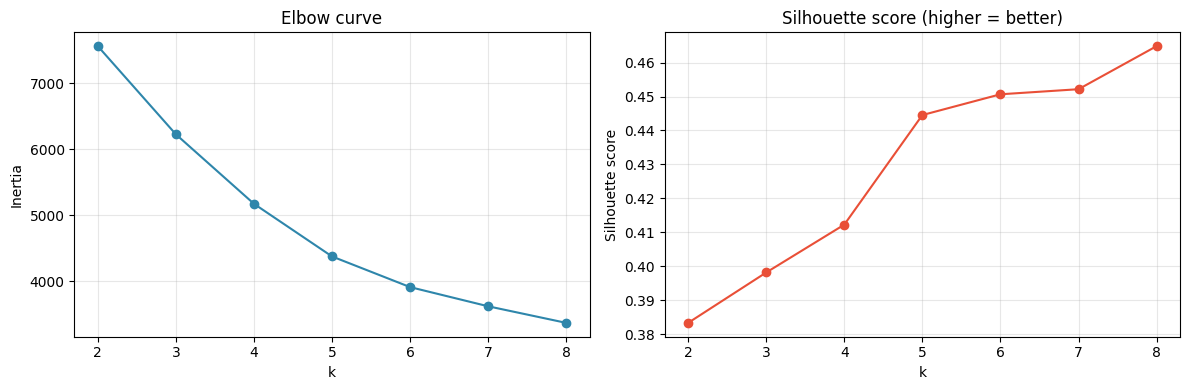

Silhouette scores: {2: np.float64(0.383), 3: np.float64(0.398), 4: np.float64(0.412), 5: np.float64(0.445), 6: np.float64(0.451), 7: np.float64(0.452), 8: np.float64(0.465)}
→ Pick k with highest silhouette score; change K_BEST below if needed


In [3]:
# ── Metric 2: Violation profile clustering ────────────────────────────────────
from sklearn.metrics import silhouette_score

llm_cols = [f"{vt}_llm" for vt in VIOLATION_TYPES if f"{vt}_llm" in df.columns]
X = df[llm_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

# ── Find optimal k via elbow + silhouette ─────────────────────────────────────
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, "o-", color="#2e86ab")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow curve")
axes[0].grid(True, alpha=0.3)
axes[1].plot(list(K_range), sil_scores, "o-", color="#e94f37")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score (higher = better)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "metric2a_cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Silhouette scores:", {k: round(s, 3) for k, s in zip(K_range, sil_scores)})
print("→ Pick k with highest silhouette score; change K_BEST below if needed")

PCA variance explained: 56.8%

Cluster labels: {0: 'Coupling-heavy', 1: 'Clean', 2: 'Coupling-heavy', 3: 'Method-smell'}

Cluster sizes:
   cluster   cluster_label    n
0        0  Coupling-heavy  440
1        1           Clean  103
2        2  Coupling-heavy  100
3        3    Method-smell   89


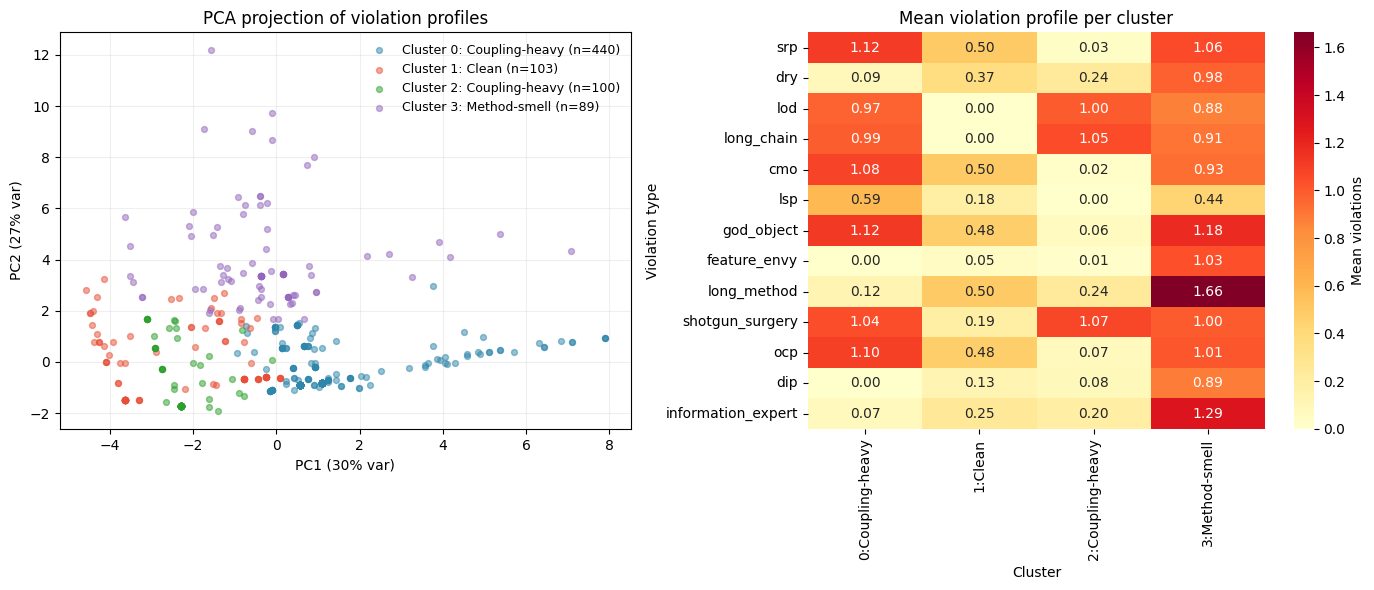

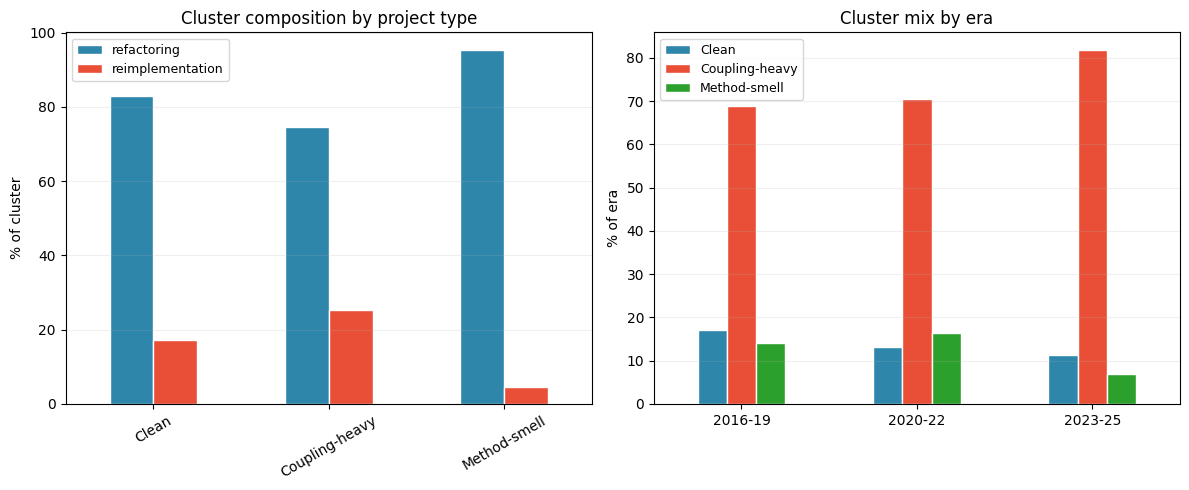

In [4]:
# ── Fit final clustering with chosen k ───────────────────────────────────────
K_BEST = 4   # ← change this if elbow/silhouette suggest different k

km = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
df["cluster"] = km.fit_predict(X_scaled)

# ── PCA 2D projection for scatter ────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df["pca1"] = coords[:, 0]
df["pca2"] = coords[:, 1]
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}")

# ── Cluster profiles (mean LLM violations per type) ──────────────────────────
cluster_profiles = df.groupby("cluster")[llm_cols].mean()
cluster_profiles.columns = [c.replace("_llm", "") for c in cluster_profiles.columns]

# Auto-label clusters by their dominant violation category
def label_cluster(row):
    coupling_score = row[["lod","long_chain","shotgun_surgery"]].mean()
    class_score    = row[["srp","god_object","cmo","ocp","lsp"]].mean()
    method_score   = row[["feature_envy","long_method","dry","dip","information_expert"]].mean()
    total          = row.mean()
    if total < 0.3:
        return "Clean"
    if coupling_score >= class_score and coupling_score >= method_score:
        return "Coupling-heavy"
    if class_score >= coupling_score and class_score >= method_score:
        return "Class-bloat"
    return "Method-smell"

cluster_labels = {i: label_cluster(cluster_profiles.loc[i]) for i in range(K_BEST)}
df["cluster_label"] = df["cluster"].map(cluster_labels)
print("\nCluster labels:", cluster_labels)
print("\nCluster sizes:")
print(df.groupby(["cluster","cluster_label"]).size().reset_index(name="n"))

# ── Plot 1: PCA scatter coloured by cluster ───────────────────────────────────
cluster_colors = ["#2e86ab","#e94f37","#2ca02c","#9467bd","#8c564b","#e377c2"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for c in range(K_BEST):
    mask = df["cluster"] == c
    ax.scatter(df.loc[mask, "pca1"], df.loc[mask, "pca2"],
               s=18, alpha=0.5, color=cluster_colors[c],
               label=f"Cluster {c}: {cluster_labels[c]} (n={mask.sum()})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
ax.set_title("PCA projection of violation profiles")
ax.legend(fontsize=9, frameon=False)
ax.grid(True, alpha=0.2)

# Plot 2: Heatmap of cluster profiles
ax2 = axes[1]
sns.heatmap(cluster_profiles.T, annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "Mean violations"}, ax=ax2,
            xticklabels=[f"{i}:{cluster_labels[i]}" for i in range(K_BEST)])
ax2.set_title("Mean violation profile per cluster")
ax2.set_xlabel("Cluster")
ax2.set_ylabel("Violation type")
plt.tight_layout()
plt.savefig(FIG_DIR / "metric2b_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Cluster composition by project category and semester era ──────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# By project category
if "project_category" in df.columns:
    ct = pd.crosstab(df["cluster_label"], df["project_category"], normalize="index") * 100
    ct.plot(kind="bar", ax=axes[0], color=["#2e86ab","#e94f37"], edgecolor="white")
    axes[0].set_title("Cluster composition by project type")
    axes[0].set_ylabel("% of cluster")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.2, axis="y")

# By era
df["era"] = pd.cut(df["year"], bins=[2015,2019,2022,2026],
                   labels=["2016-19","2020-22","2023-25"])
era_ct = pd.crosstab(df["era"], df["cluster_label"], normalize="index") * 100
era_ct.plot(kind="bar", ax=axes[1], color=cluster_colors[:K_BEST], edgecolor="white")
axes[1].set_title("Cluster mix by era")
axes[1].set_ylabel("% of era")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig(FIG_DIR / "metric2c_cluster_composition.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Metric 3: Violation Persistence Across Semesters
For each violation type, what % of semesters had a mean > 0.5 violations/project?
Reveals which design smells are chronic vs. sporadic — and whether 10 years of instruction has reduced any of them.

=== Violation Persistence (threshold = mean > 0.5/project) ===
         violation     category  n_sems_present  persistence_pct  overall_mean  trend_slope
               srp  class-level              20             1.00         0.886       0.0068
               cmo  class-level              20             1.00         0.848       0.0093
        god_object  class-level              20             1.00         0.898       0.0073
   shotgun_surgery     coupling              20             1.00         0.920       0.0131
               ocp  class-level              20             1.00         0.863       0.0105
               lod     coupling              19             0.95         0.825       0.0041
        long_chain     coupling              19             0.95         0.855       0.0044
       long_method method-level               4             0.20         0.373      -0.0016
               lsp  class-level               2             0.10         0.427       0.0011
               dr

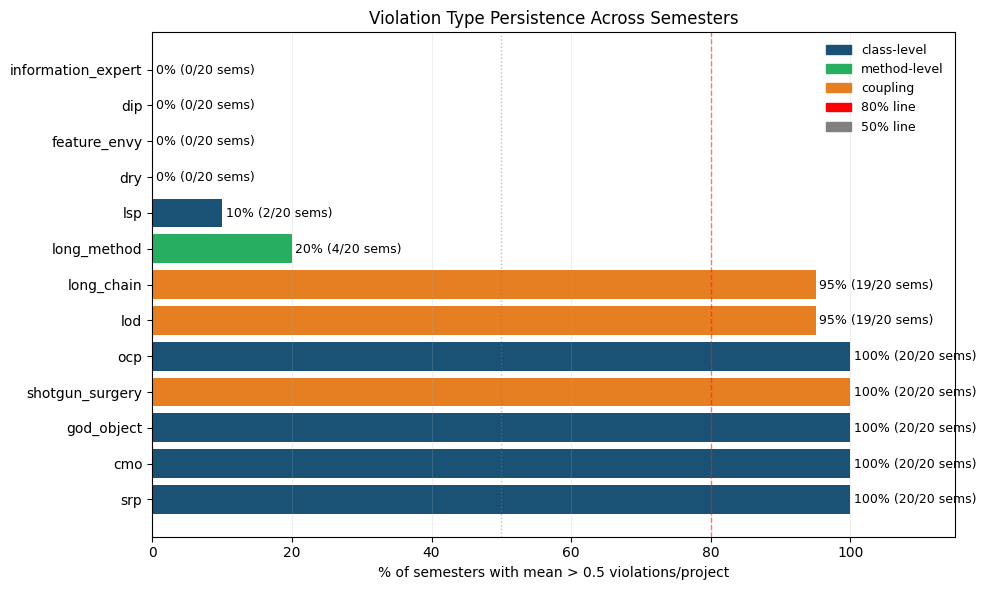


Violations present in ≥70% of semesters: ['srp', 'cmo', 'god_object', 'shotgun_surgery', 'ocp', 'lod', 'long_chain']


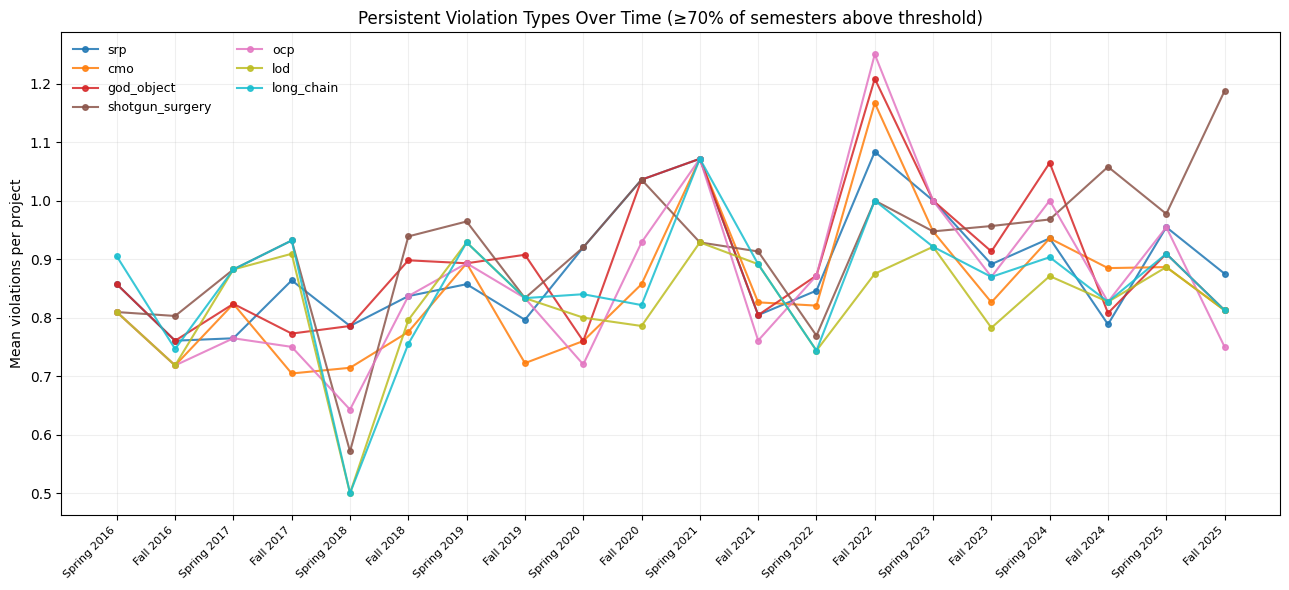


=== Trend slopes (positive = worsening, negative = improving over time) ===
         violation  trend_slope
      feature_envy      -0.0027
information_expert      -0.0027
       long_method      -0.0016
               dip      -0.0016
               dry       0.0001
               lsp       0.0011
               lod       0.0041
        long_chain       0.0044
               srp       0.0068
        god_object       0.0073
               cmo       0.0093
               ocp       0.0105
   shotgun_surgery       0.0131


In [5]:
# ── Metric 3: Violation persistence ──────────────────────────────────────────
THRESHOLD = 0.5   # mean violations/project to count a semester as "present"

sem_order = df.groupby("semester").agg({"sort_key": "first"}).reset_index()
semesters = sem_order.sort_values("sort_key")["semester"].tolist()
n_sems = len(semesters)

persist_rows = []
for vt in VIOLATION_TYPES:
    col = f"{vt}_llm"
    if col not in df.columns:
        continue
    sem_means = df.groupby("semester")[col].mean().reindex(semesters)
    n_present = (sem_means > THRESHOLD).sum()
    persist_pct = n_present / n_sems

    # Trend: is the mean rising or falling over time?
    valid = sem_means.dropna()
    if len(valid) >= 4:
        x = np.arange(len(valid))
        slope = np.polyfit(x, valid.values, 1)[0]
    else:
        slope = np.nan

    if vt in CLASS_LEVEL:   cat = "class-level"
    elif vt in METHOD_LEVEL: cat = "method-level"
    else:                    cat = "coupling"

    persist_rows.append({
        "violation": vt,
        "category": cat,
        "n_sems_present": int(n_present),
        "persistence_pct": round(persist_pct, 3),
        "overall_mean": round(sem_means.mean(), 3),
        "trend_slope": round(slope, 4) if not np.isnan(slope) else np.nan,
    })

persist_df = pd.DataFrame(persist_rows).sort_values("persistence_pct", ascending=False)
print(f"=== Violation Persistence (threshold = mean > {THRESHOLD}/project) ===")
print(persist_df.to_string(index=False))

# ── Plot 1: Persistence bar chart ─────────────────────────────────────────────
cat_colors = {"class-level": "#1a5276", "method-level": "#27ae60", "coupling": "#e67e22"}
colors = [cat_colors[persist_df.loc[i, "category"]] for i in persist_df.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(persist_df["violation"], persist_df["persistence_pct"] * 100, color=colors)
ax.axvline(80, color="red", linestyle="--", alpha=0.5, linewidth=1, label="80% threshold")
ax.axvline(50, color="gray", linestyle=":", alpha=0.5, linewidth=1, label="50% threshold")
for i, (v, p) in enumerate(zip(persist_df["violation"], persist_df["persistence_pct"])):
    ax.text(p * 100 + 0.5, i, f"{p:.0%} ({persist_df.iloc[i]['n_sems_present']}/{n_sems} sems)",
            va="center", fontsize=9)
ax.set_xlabel(f"% of semesters with mean > {THRESHOLD} violations/project")
ax.set_title("Violation Type Persistence Across Semesters")
ax.set_xlim(0, 115)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis="x")
legend_patches = [mpatches.Patch(color=c, label=k) for k, c in cat_colors.items()]
ax.legend(handles=legend_patches + [mpatches.Patch(color="red",label="80% line"),
           mpatches.Patch(color="gray",label="50% line")], fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "metric3a_persistence.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Per-semester trend lines for most persistent violations ────────────
top_persistent = persist_df[persist_df["persistence_pct"] >= 0.7]["violation"].tolist()
print(f"\nViolations present in ≥70% of semesters: {top_persistent}")

if top_persistent:
    fig, ax = plt.subplots(figsize=(13, 6))
    palette = plt.cm.tab10(np.linspace(0, 1, len(top_persistent)))
    x = range(len(semesters))
    for i, vt in enumerate(top_persistent):
        col = f"{vt}_llm"
        means = df.groupby("semester")[col].mean().reindex(semesters)
        ax.plot(x, means, "o-", label=vt, linewidth=1.5, markersize=4,
                color=palette[i], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(semesters, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Mean violations per project")
    ax.set_title("Persistent Violation Types Over Time (≥70% of semesters above threshold)")
    ax.legend(fontsize=9, ncol=2, frameon=False)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "metric3b_persistent_trends.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Trend direction summary ───────────────────────────────────────────────────
print("\n=== Trend slopes (positive = worsening, negative = improving over time) ===")
print(persist_df[["violation","trend_slope"]].sort_values("trend_slope").to_string(index=False))

---
## Metric 4: Alignment Score vs. Violation Count Breakdown
Does the LLM's violation count actually predict instructor alignment?
Tests whether the system's severity judgment correlates with instructor feedback direction.

Rows with valid alignment scores: 732

Pearson r (total violations vs alignment): -0.138, p=0.0002
  → Significant: more violations → lower alignment score

=== Per-violation-type correlation with alignment score ===
         violation      r      p
        god_object -0.155 0.0000
               ocp -0.123 0.0009
               srp -0.121 0.0011
      feature_envy -0.112 0.0023
               cmo -0.102 0.0056
               lod -0.083 0.0250
   shotgun_surgery -0.080 0.0309
               lsp -0.045 0.2225
        long_chain -0.030 0.4140
information_expert -0.030 0.4104
               dip -0.018 0.6249
       long_method -0.014 0.7073
               dry  0.003 0.9391
  (negative r = more violations → lower alignment score = correct direction)

=== Avg violations by alignment bin ===
              n  mean_llm  mean_static
align_bin                             
Low (1-2)   413      8.49        35.89
Mid (3)     110      4.37        39.39
High (4-5)  209      7.75        39.10


/var/folders/xs/n8x_3wvj1275wzhw5q2smc080000gn/T/ipykernel_95776/2673226114.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_bin, labels=bins, patch_artist=True,


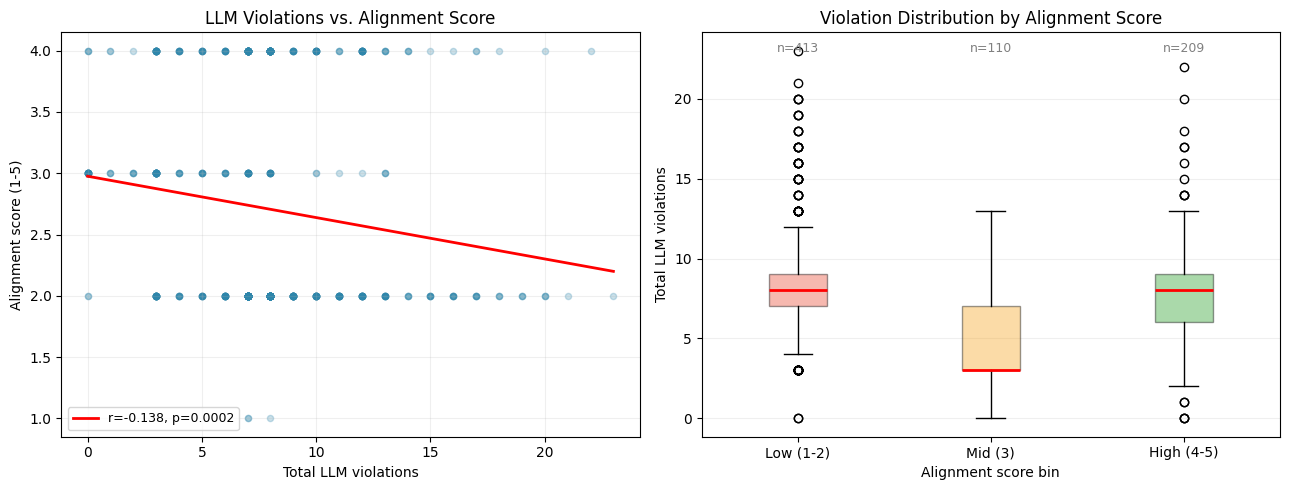

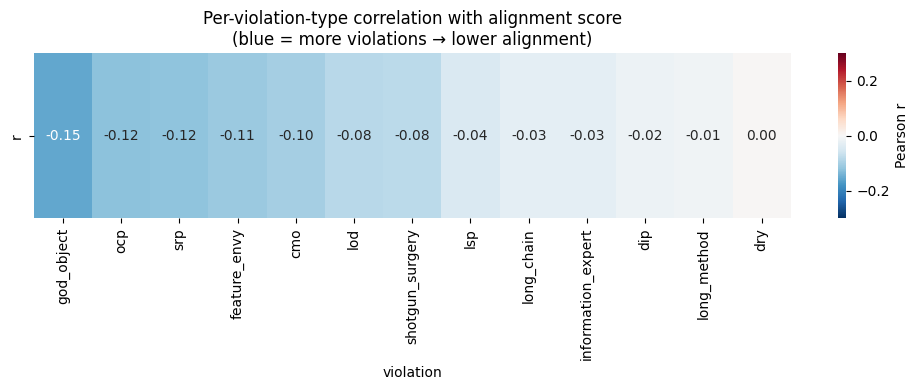

In [6]:
# ── Metric 4: Alignment score vs. violation count ─────────────────────────────
if "alignment_score" not in df.columns:
    print("No alignment_score column found — skipping this metric.")
else:
    align_df = df.dropna(subset=["alignment_score", "total_llm_violations"]).copy()
    align_df = align_df[align_df["alignment_score"].between(1, 5)]
    print(f"Rows with valid alignment scores: {len(align_df)}")

    # Overall Pearson correlation
    r, p = pearsonr(align_df["total_llm_violations"], align_df["alignment_score"])
    print(f"\nPearson r (total violations vs alignment): {r:.3f}, p={p:.4f}")
    if p < 0.05:
        direction = "higher" if r > 0 else "lower"
        print(f"  → Significant: more violations → {direction} alignment score")
    else:
        print("  → Not significant at p<0.05")

    # Per-type correlation with alignment
    type_corr = []
    for vt in VIOLATION_TYPES:
        col = f"{vt}_llm"
        if col not in align_df.columns:
            continue
        sub = align_df[[col, "alignment_score"]].dropna()
        if sub[col].std() == 0:
            continue
        r2, p2 = pearsonr(sub[col], sub["alignment_score"])
        type_corr.append({"violation": vt, "r": round(r2, 3), "p": round(p2, 4)})
    corr_df = pd.DataFrame(type_corr).sort_values("r")
    print("\n=== Per-violation-type correlation with alignment score ===")
    print(corr_df.to_string(index=False))
    print("  (negative r = more violations → lower alignment score = correct direction)")

    # Bin alignment scores and compare violation profiles
    align_df["align_bin"] = pd.cut(
        align_df["alignment_score"],
        bins=[0, 2, 3, 5],
        labels=["Low (1-2)", "Mid (3)", "High (4-5)"]
    )
    bin_stats = align_df.groupby("align_bin", observed=True).agg(
        n=("total_llm_violations", "count"),
        mean_llm=("total_llm_violations", "mean"),
        mean_static=("total_static_violations", "mean") if "total_static_violations" in align_df.columns else ("total_llm_violations", "mean"),
    ).round(2)
    print("\n=== Avg violations by alignment bin ===")
    print(bin_stats)

    # ── Plot 1: Scatter with regression line ──────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.scatter(align_df["total_llm_violations"], align_df["alignment_score"],
               alpha=0.25, s=20, color="#2e86ab")
    m, b = np.polyfit(align_df["total_llm_violations"], align_df["alignment_score"], 1)
    xline = np.linspace(align_df["total_llm_violations"].min(),
                        align_df["total_llm_violations"].max(), 100)
    ax.plot(xline, m * xline + b, "r-", linewidth=2, label=f"r={r:.3f}, p={p:.4f}")
    ax.set_xlabel("Total LLM violations")
    ax.set_ylabel("Alignment score (1-5)")
    ax.set_title("LLM Violations vs. Alignment Score")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

    # Plot 2: Box plots of violations by alignment bin
    ax2 = axes[1]
    bins = ["Low (1-2)", "Mid (3)", "High (4-5)"]
    data_by_bin = [align_df[align_df["align_bin"] == b]["total_llm_violations"].dropna().values
                   for b in bins]
    bp = ax2.boxplot(data_by_bin, labels=bins, patch_artist=True,
                     medianprops={"color": "red", "linewidth": 2})
    colors3 = ["#e94f37", "#f6a623", "#2ca02c"]
    for patch, color in zip(bp["boxes"], colors3):
        patch.set_facecolor(color)
        patch.set_alpha(0.4)
    ax2.set_xlabel("Alignment score bin")
    ax2.set_ylabel("Total LLM violations")
    ax2.set_title("Violation Distribution by Alignment Score")
    for i, d in enumerate(data_by_bin):
        ax2.text(i + 1, ax2.get_ylim()[1] * 0.95, f"n={len(d)}",
                 ha="center", fontsize=9, color="gray")
    ax2.grid(True, alpha=0.2, axis="y")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "metric4a_alignment_vs_violations.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Plot 2: Per-type heatmap of correlation with alignment ─────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    corr_pivot = corr_df.set_index("violation")[["r"]].T
    sns.heatmap(corr_pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-0.3, vmax=0.3, ax=ax, cbar_kws={"label": "Pearson r"})
    ax.set_title("Per-violation-type correlation with alignment score\n(blue = more violations → lower alignment)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "metric4b_alignment_type_corr.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## Metric 5: Early vs. Recent Cohort Comparison (Longitudinal Change)
Split into three eras and run t-tests per violation type.
Reveals whether violation patterns have changed over the decade — and which ones have improved, worsened, or stayed flat.

Early cohort (≤2019): n=351
Recent cohort (≥2022): n=381

=== Early vs. Recent Cohort Comparison ===
         violation     category  mean_early  mean_recent  mean_diff  p_value  significant direction
      feature_envy method-level       0.168        0.105     -0.063   0.0599        False  improved
information_expert method-level       0.282        0.241     -0.041   0.5740        False  improved
       long_method method-level       0.387        0.373     -0.015   0.9811        False  improved
               dip method-level       0.142        0.134     -0.009   0.7644        False  improved
               dry method-level       0.256        0.255     -0.002   0.9343        False  improved
               lsp  class-level       0.419        0.449      0.030   0.8401        False  worsened
               lod     coupling       0.803        0.850      0.047   0.1046        False  worsened
        long_chain     coupling       0.818        0.882      0.064   0.0869        False  worsened

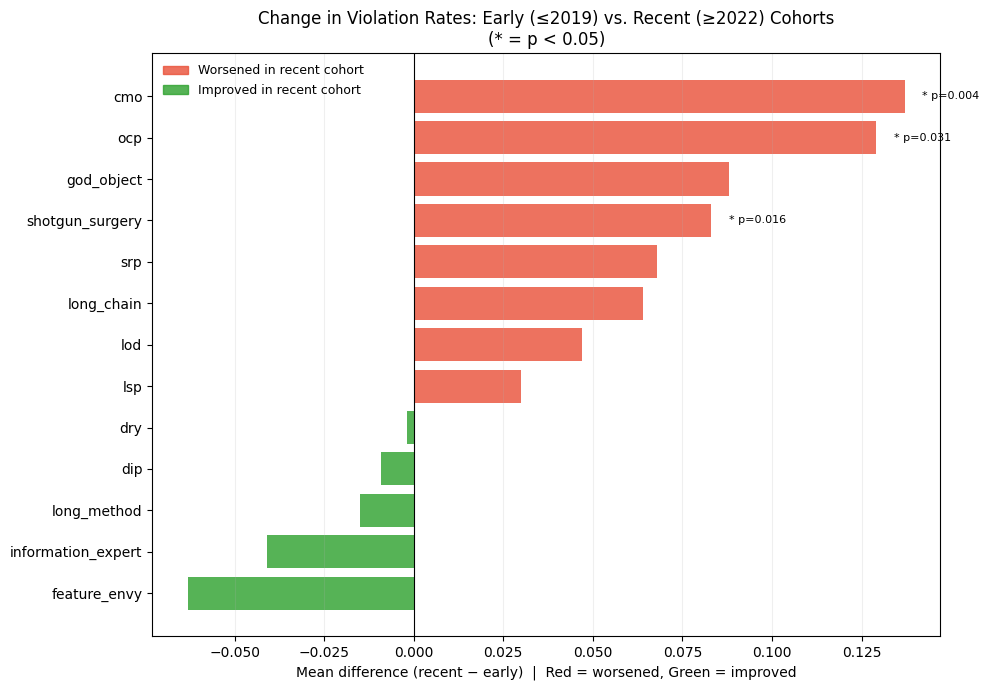

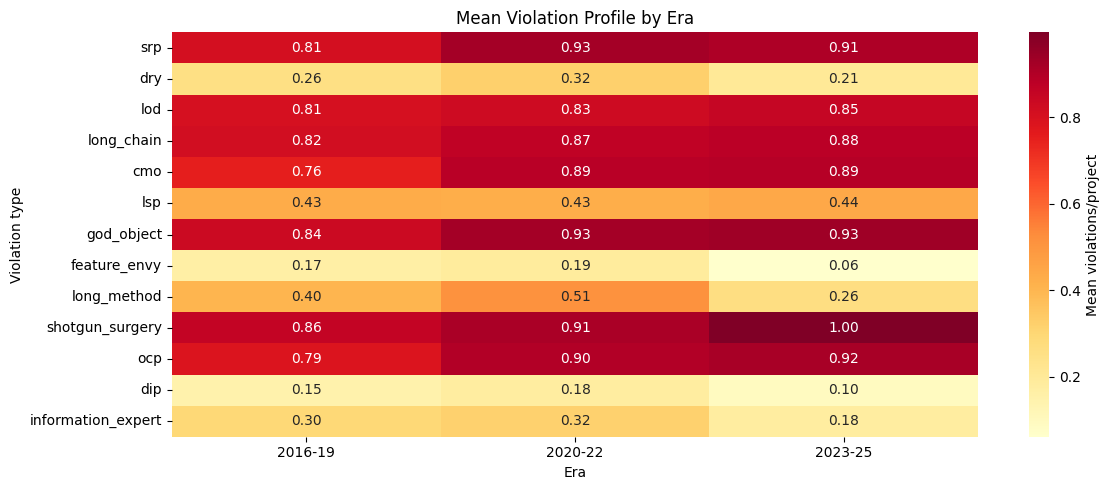

In [ ]:
# ── Metric 5: Early vs. recent cohort comparison ──────────────────────────────
from scipy.stats import mannwhitneyu   # more robust than t-test for skewed counts

era_early  = df[df["year"] <= 2019]

era_recent = df[df["year"] >= 2022]
print(f"Early cohort (≤2019): n={len(era_early)}")
print(f"Recent cohort (≥2022): n={len(era_recent)}")

era_rows = []
for vt in VIOLATION_TYPES:
    col = f"{vt}_llm"
    if col not in df.columns:
        continue
    a = era_early[col].dropna()
    b = era_recent[col].dropna()
    if len(a) < 5 or len(b) < 5:
        continue
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    mean_diff = b.mean() - a.mean()

    if vt in CLASS_LEVEL:    cat = "class-level"
    elif vt in METHOD_LEVEL: cat = "method-level"
    else:                    cat = "coupling"

    era_rows.append({
        "violation": vt, "category": cat,
        "mean_early": round(a.mean(), 3),
        "mean_recent": round(b.mean(), 3),
        "mean_diff": round(mean_diff, 3),
        "p_value": round(p, 4),
        "significant": p < 0.05,
        "direction": "worsened" if mean_diff > 0 else "improved",
    })

era_df = pd.DataFrame(era_rows).sort_values("mean_diff")
print("\n=== Early vs. Recent Cohort Comparison ===")
print(era_df.to_string(index=False))
print(f"\nSignificant changes (p<0.05): {era_df[era_df.significant]['violation'].tolist()}")

# ── Plot: Diverging bar chart of mean difference ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e94f37" if d > 0 else "#2ca02c" for d in era_df["mean_diff"]]
bars = ax.barh(era_df["violation"], era_df["mean_diff"], color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)

# Mark significant results with *
for i, (_, row) in enumerate(era_df.iterrows()):
    if row["significant"]:
        xpos = row["mean_diff"] + (0.005 if row["mean_diff"] >= 0 else -0.005)
        ha = "left" if row["mean_diff"] >= 0 else "right"
        ax.text(xpos, i, f"* p={row['p_value']:.3f}", va="center", fontsize=8, ha=ha)

ax.set_xlabel("Mean difference (recent − early)  |  Red = worsened, Green = improved")
ax.set_title("Change in Violation Rates: Early (≤2019) vs. Recent (≥2022) Cohorts\n(* = p < 0.05)")
ax.grid(True, alpha=0.2, axis="x")

legend_patches = [
    mpatches.Patch(color="#e94f37", alpha=0.8, label="Worsened in recent cohort"),
    mpatches.Patch(color="#2ca02c", alpha=0.8, label="Improved in recent cohort"),
]
ax.legend(handles=legend_patches, fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "metric5_cohort_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-era mean profiles ─────────────────────────────────────────────────────
df["era"] = pd.cut(df["year"], bins=[2015,2019,2022,2026],
                   labels=["2016-19","2020-22","2023-25"])
era_profile = df.groupby("era", observed=True)[[f"{v}_llm" for v in VIOLATION_TYPES]].mean()
era_profile.columns = [c.replace("_llm","") for c in era_profile.columns]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(era_profile.T, annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "Mean violations/project"}, ax=ax)
ax.set_title("Mean Violation Profile by Era")
ax.set_xlabel("Era")
ax.set_ylabel("Violation type")
plt.tight_layout()
plt.savefig(FIG_DIR / "metric5b_era_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Metric 6: Weighted Severity Score
Architectural violations (OCP, shotgun surgery, LoD) carry more weight than local smells (long method, DRY).
Tests whether a calibrated severity score predicts alignment better than raw count.

Severity score summary:
count    732.00
mean      17.75
std        7.43
min        0.00
25%       14.00
50%       18.00
75%       20.00
max       47.00
Name: severity_score, dtype: float64

Raw count vs alignment:     r=-0.138, p=0.0002
Severity score vs alignment: r=-0.145, p=0.0001
→ Weighted severity is a better predictor of alignment than raw count

Severity by project category:
                  mean  median   std
project_category                    
refactoring       17.7    19.0  7.39
reimplementation  18.0    18.0  7.49


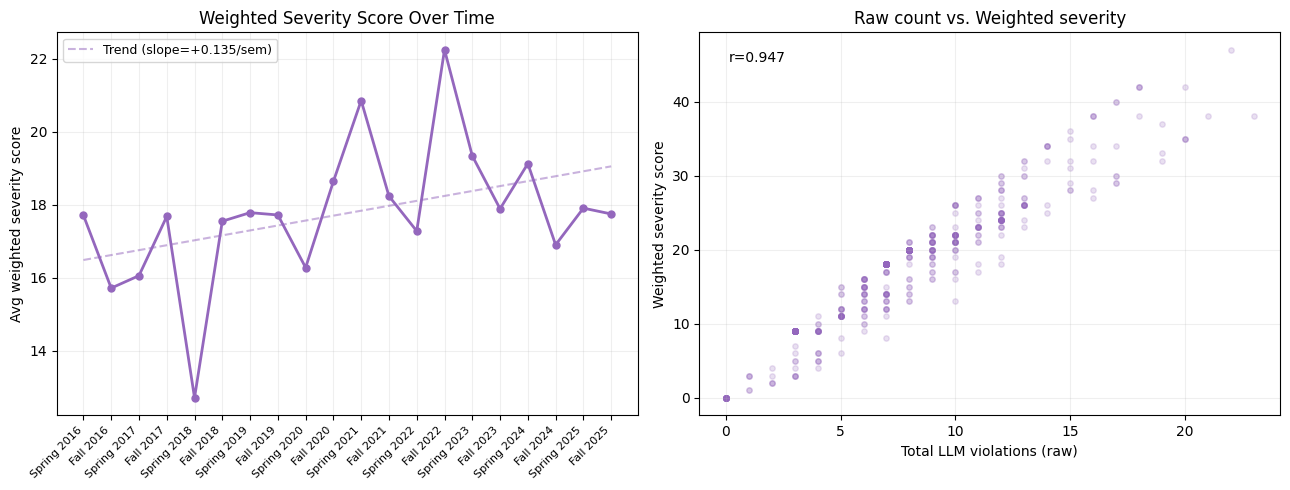

In [8]:
# ── Metric 6: Weighted severity score ─────────────────────────────────────────
# Weights reflect architectural impact: coupling/OCP = 3, class-level = 2, method-level = 1
SEVERITY_WEIGHTS = {
    "ocp": 3, "shotgun_surgery": 3, "lod": 3, "long_chain": 3,
    "srp": 2, "god_object": 2, "cmo": 2, "lsp": 2, "dip": 2,
    "long_method": 1, "dry": 1, "feature_envy": 1, "information_expert": 1,
}

df["severity_score"] = sum(
    df[f"{v}_llm"] * w
    for v, w in SEVERITY_WEIGHTS.items()
    if f"{v}_llm" in df.columns
)

print("Severity score summary:")
print(df["severity_score"].describe().round(2))

if "alignment_score" in df.columns:
    align_sev = df.dropna(subset=["alignment_score","severity_score"])
    align_sev = align_sev[align_sev["alignment_score"].between(1, 5)]

    r_raw, p_raw = pearsonr(align_sev["total_llm_violations"], align_sev["alignment_score"])
    r_sev, p_sev = pearsonr(align_sev["severity_score"],       align_sev["alignment_score"])

    print(f"\nRaw count vs alignment:     r={r_raw:.3f}, p={p_raw:.4f}")
    print(f"Severity score vs alignment: r={r_sev:.3f}, p={p_sev:.4f}")
    if abs(r_sev) > abs(r_raw):
        print("→ Weighted severity is a better predictor of alignment than raw count")
    else:
        print("→ Raw count and weighted severity perform similarly")

# Severity by project category
if "project_category" in df.columns:
    sev_by_cat = df.groupby("project_category")["severity_score"].agg(["mean","median","std"]).round(2)
    print("\nSeverity by project category:")
    print(sev_by_cat)

# Severity trend over time
sem_order = df.groupby("semester").agg({"sort_key": "first"}).reset_index()
semesters = sem_order.sort_values("sort_key")["semester"].tolist()
sev_trend = df.groupby("semester")["severity_score"].mean().reindex(semesters)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x = range(len(sev_trend))
ax.plot(x, sev_trend.values, "o-", color="#9467bd", linewidth=2, markersize=5)
# Add trend line
valid_mask = ~np.isnan(sev_trend.values)
if valid_mask.sum() >= 3:
    xv = np.array(list(x))[valid_mask]
    yv = sev_trend.values[valid_mask]
    z = np.polyfit(xv, yv, 1)
    ax.plot(x, np.poly1d(z)(list(x)), "--", color="#9467bd", alpha=0.5, linewidth=1.5, label=f"Trend (slope={z[0]:+.3f}/sem)")
ax.set_xticks(x)
ax.set_xticklabels(semesters, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Avg weighted severity score")
ax.set_title("Weighted Severity Score Over Time")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Severity vs raw count scatter
ax2 = axes[1]
ax2.scatter(df["total_llm_violations"], df["severity_score"],
            alpha=0.2, s=15, color="#9467bd")
ax2.set_xlabel("Total LLM violations (raw)")
ax2.set_ylabel("Weighted severity score")
ax2.set_title("Raw count vs. Weighted severity")
r2, _ = pearsonr(df["total_llm_violations"].fillna(0), df["severity_score"].fillna(0))
ax2.text(0.05, 0.95, f"r={r2:.3f}", transform=ax2.transAxes, fontsize=10, va="top")
ax2.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "metric6_severity_score.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Summary: All New Metrics at a Glance
Collect the key numbers from each metric into one printout for paper-writing.

In [9]:
# ── Summary printout ──────────────────────────────────────────────────────────
print("=" * 60)
print("SUMMARY OF NEW METRICS")
print("=" * 60)

print("\n[Metric 1] Static False-Positive Rates")
if 'fp_df' in dir():
    print(f"  Average static FP rate across all types: {fp_df['static_fp_rate'].mean():.1%}")
    worst = fp_df.iloc[0]
    print(f"  Highest FP type: {worst['violation']} at {worst['static_fp_rate']:.1%}")
    ocp_row = fp_df[fp_df.violation == 'ocp']
    if len(ocp_row):
        print(f"  OCP LLM-only rate: {ocp_row.iloc[0]['llm_semantic_rate']:.1%} (static blind to it)")

print("\n[Metric 2] Clustering")
if 'df' in dir() and 'cluster_label' in df.columns:
    print(df.groupby("cluster_label").size().to_string())

print("\n[Metric 3] Persistence")
if 'persist_df' in dir():
    always = persist_df[persist_df.persistence_pct >= 0.9]
    never  = persist_df[persist_df.persistence_pct < 0.3]
    print(f"  Always present (≥90% sems): {always['violation'].tolist()}")
    print(f"  Rarely present (<30% sems): {never['violation'].tolist()}")

print("\n[Metric 4] Alignment Correlation")
if 'r' in dir() and 'p' in dir():
    print(f"  Total violations vs alignment: r={r:.3f}, p={p:.4f}")

print("\n[Metric 5] Cohort Comparison")
if 'era_df' in dir():
    sig = era_df[era_df.significant]
    if len(sig):
        print(f"  Significant changes: {sig[['violation','mean_diff','p_value']].to_string(index=False)}")
    else:
        print("  No significant changes detected between early and recent cohorts")

print("\n[Metric 6] Severity Score")
if 'r_sev' in dir():
    print(f"  Severity vs alignment: r={r_sev:.3f}, p={p_sev:.4f}")
    print(f"  Raw count vs alignment: r={r_raw:.3f}, p={p_raw:.4f}")

print("\n" + "=" * 60)

SUMMARY OF NEW METRICS

[Metric 1] Static False-Positive Rates
  Average static FP rate across all types: 42.8%
  Highest FP type: feature_envy at 86.0%
  OCP LLM-only rate: 100.0% (static blind to it)

[Metric 2] Clustering
cluster_label
Clean             103
Coupling-heavy    540
Method-smell       89

[Metric 3] Persistence
  Always present (≥90% sems): ['srp', 'cmo', 'god_object', 'shotgun_surgery', 'ocp', 'lod', 'long_chain']
  Rarely present (<30% sems): ['long_method', 'lsp', 'dry', 'feature_envy', 'dip', 'information_expert']

[Metric 4] Alignment Correlation
  Total violations vs alignment: r=-0.138, p=0.1835

[Metric 5] Cohort Comparison
  Significant changes:       violation  mean_diff  p_value
   feature_envy     -0.084   0.0144
shotgun_surgery      0.110   0.0054
            cmo      0.148   0.0054
            ocp      0.152   0.0200

[Metric 6] Severity Score
  Severity vs alignment: r=-0.145, p=0.0001
  Raw count vs alignment: r=-0.138, p=0.0002

